In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
# Check for missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1.Handle missing values

In [7]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# 2.Feature Engineering

In [9]:
# Convert YearBirth to Age
df["Age"]= 2026 - df["Year_Birth"]

In [10]:
df["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2240, dtype: int64

In [11]:
# Converting Dt_Customer into Customer Tenure Days
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"] , dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [14]:
# Spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [16]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [18]:
# reduce education categories from 5 to 3 

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate" , "2n Cycle":"Undergraduate" ,
    "Graduation":"Graduate" ,
    "PhD":"Postgraduate","Master":"Postgraduate"
})

In [20]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [21]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [22]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner" , "Together":"Partner",
     "Single":"Alone" , "Divorced":"Alone", "Widow":"Alone", "Alone":"Alone" , "Absurd":"Alone", "YOLO":"Alone"
})

In [23]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

##  Drop Columns

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [25]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

cols_to_drop=cols+spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [26]:
df.shape

(2240, 27)

In [27]:
df_cleaned.shape

(2240, 15)

In [28]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

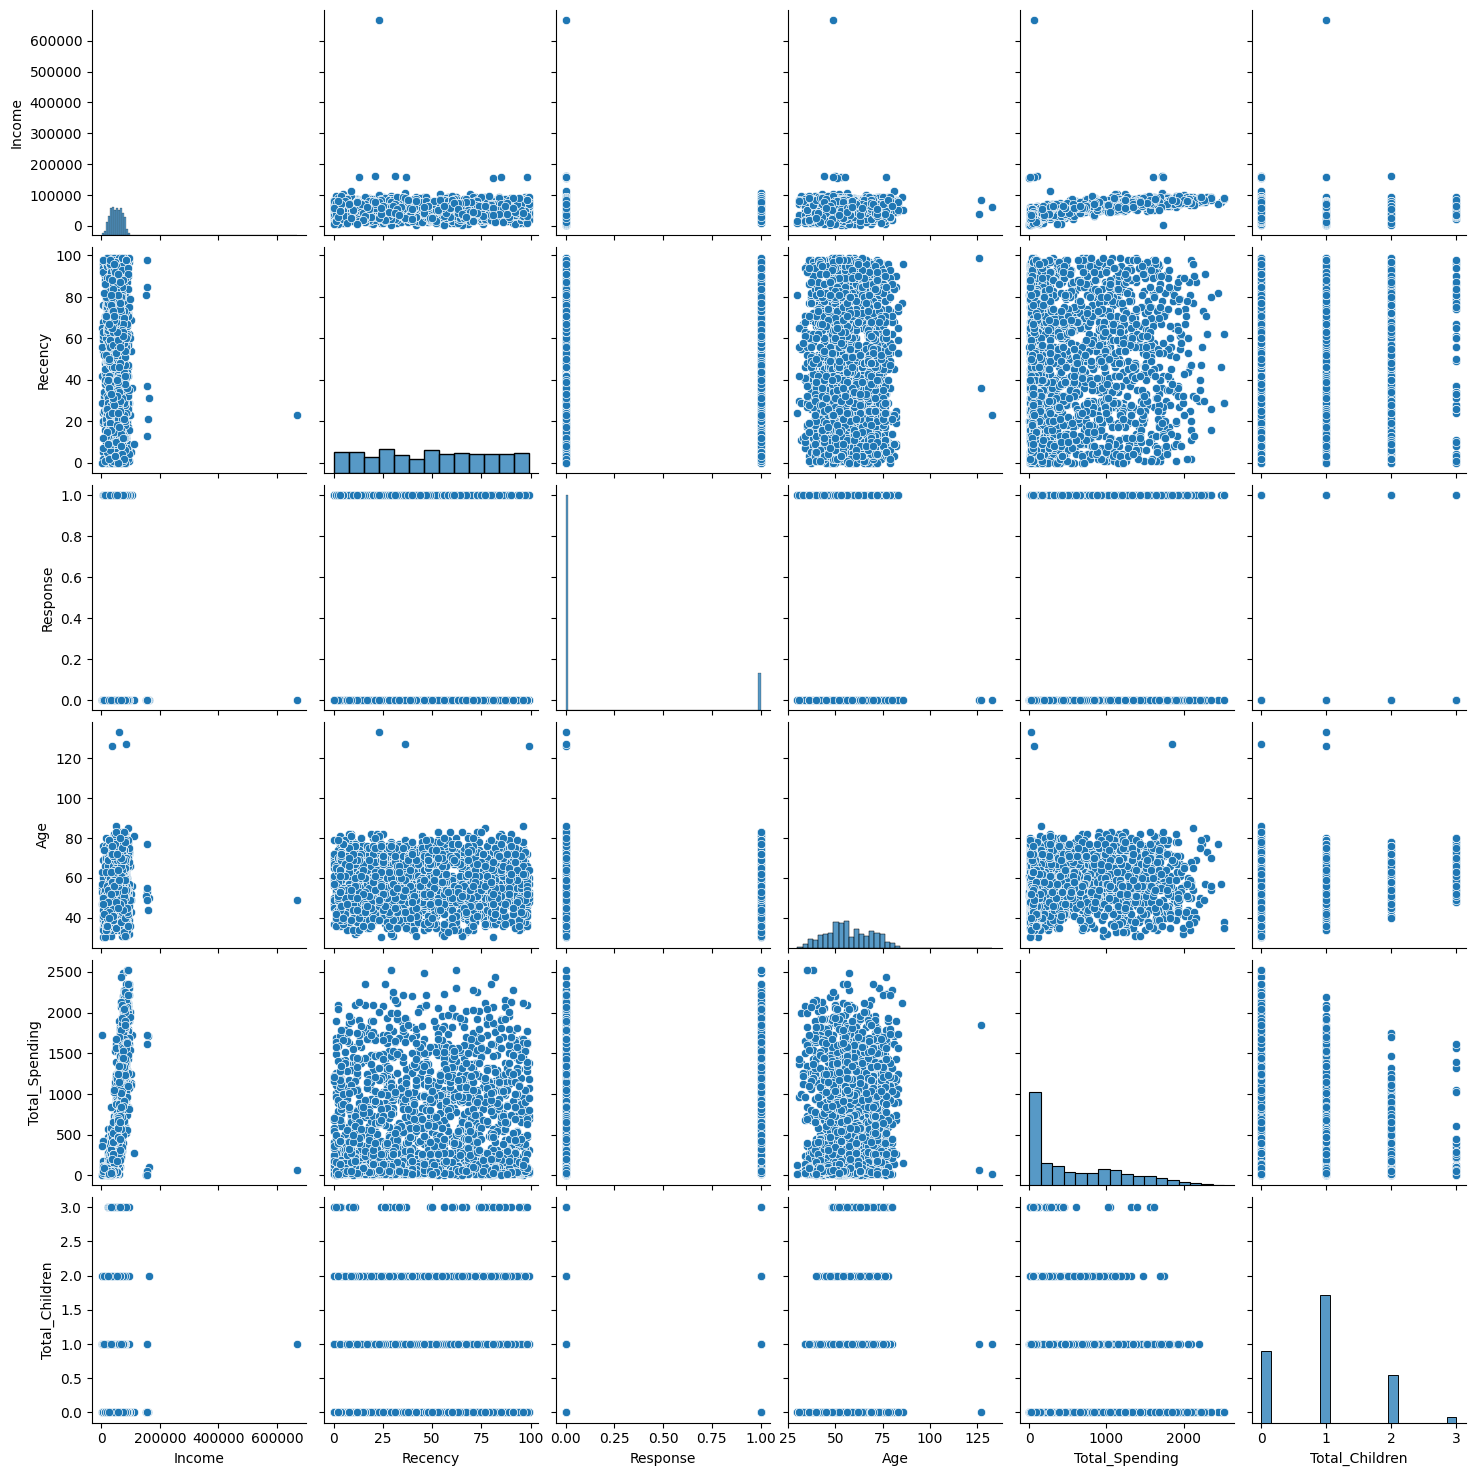

In [29]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

sns.pairplot(df_cleaned[cols])

In [30]:
# there are 2 outliers
# 1 . Income>600000
# 2. Age>120

In [31]:
# Remove Outliers

print("Data size with outliers=", len(df_cleaned))

df_cleaned  = df_cleaned[ (df_cleaned["Income"] < 600_000) ]
df_cleaned= df_cleaned[(df_cleaned["Age"] < 90 )]

print("Data size without outliers=", len(df_cleaned))

Data size with outliers= 2240
Data size without outliers= 2236


# Heatmap

In [32]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

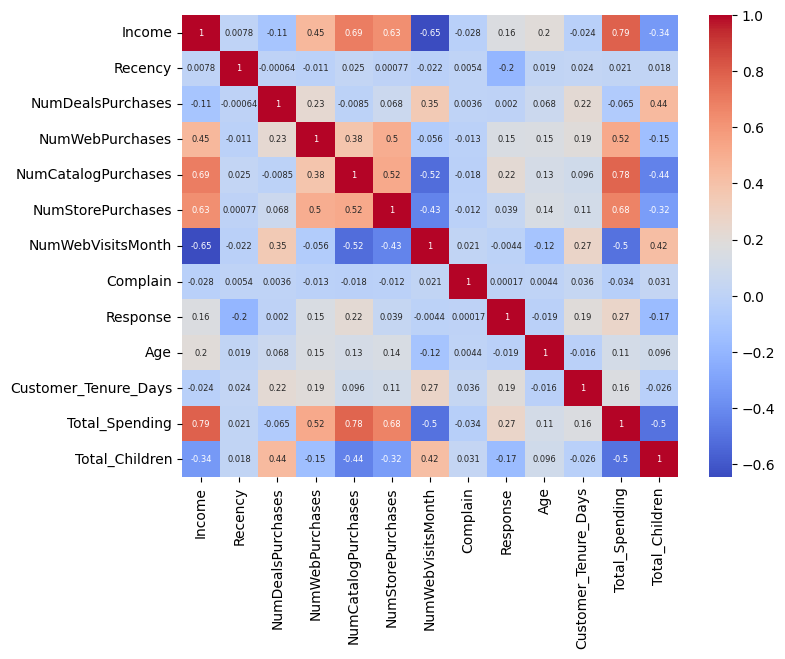

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size":6}
)

# Encoding

In [34]:
from sklearn.preprocessing import OneHotEncoder

In [35]:
ohe=OneHotEncoder()

cat_cols=["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [36]:
enc_df = pd.DataFrame(enc_cols.toarray() , columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [37]:
# we generally dont dropfirst here in unsupervised learning as there is no collinearity involved in cluster formation
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [39]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols) , enc_df] , axis=1)

In [40]:
df_encoded.shape

(2236, 18)

# Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
X=df_encoded

In [44]:
scaler = StandardScaler()

X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualization

In [45]:
# 2d visualization
from sklearn.decomposition import PCA

In [47]:
pca = PCA(
    n_components=2
)
X_pca = pca.fit_transform(X_scaled)

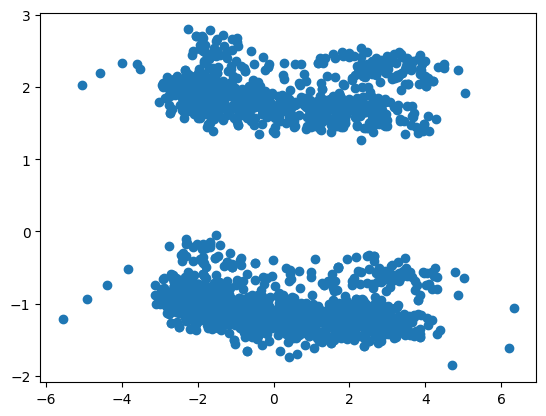

In [48]:
# plot 

plt.scatter(X_pca[:,0] , X_pca[:,1])

In [50]:
pca.explained_variance_ratio_
# It captures only 34% variance which is very less due to less dimensions (18->2)

array([0.23163158, 0.11385454])

In [52]:
# 3d
pca = PCA(
    n_components=3
)
X_pca = pca.fit_transform(X_scaled)

In [53]:
pca.explained_variance_ratio_
# 44% variance captured 

array([0.23163158, 0.11385454, 0.10405815])

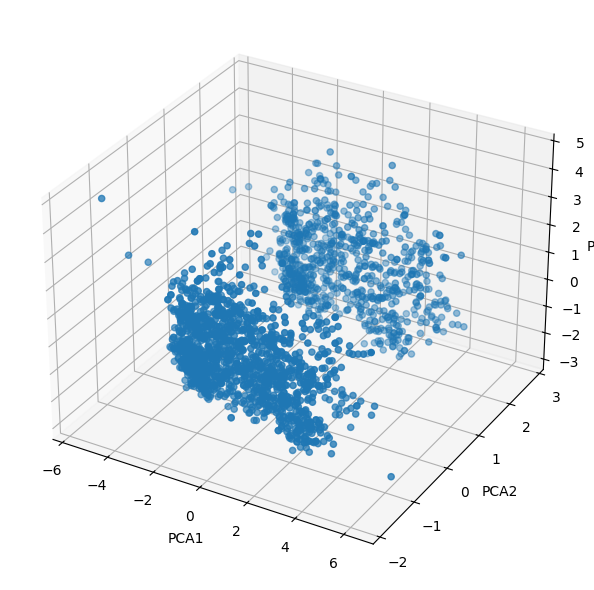

In [58]:
fig=plt.figure(figsize=(12,6))

ax = fig.add_subplot(111 , projection="3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

fig.tight_layout()

# Analyzing K
## 1.Elbow Score

In [59]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [61]:
wcss=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

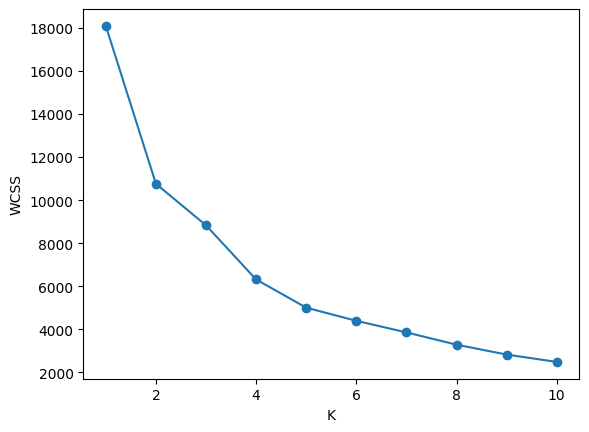

In [66]:
plt.plot(range(1,11) , wcss , marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")

In [64]:
knee=KneeLocator(x=range(1,11) , y=wcss, curve="convex",direction="decreasing")
print(knee.elbow)

4


## 2 . Silhouette score

Text(0, 0.5, 'Silhouette')

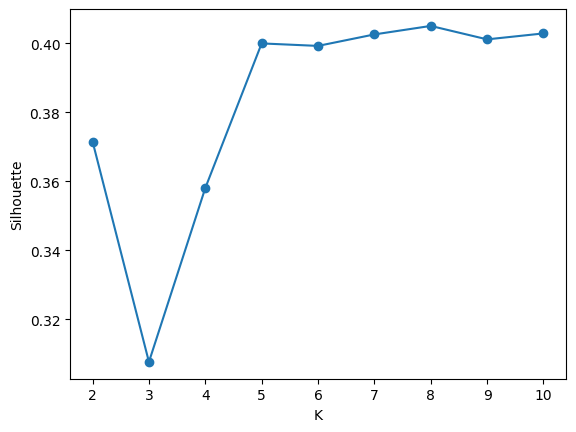

In [72]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

plt.plot(range(2,11) , scores , marker="o")

plt.xlabel("K")
plt.ylabel("Silhouette")

Text(0, 0.5, 'SS')

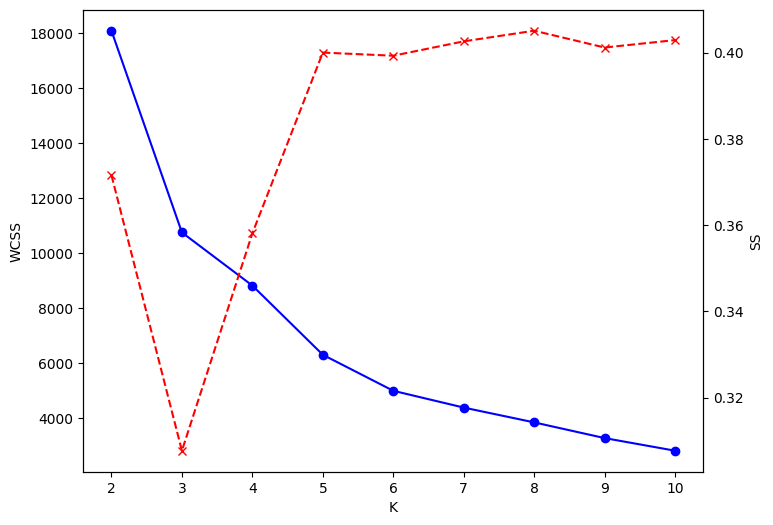

In [82]:
# Combine both methods
k_range=range(2,11)

fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)] , marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()  #keeping x-axis same
ax2.plot(k_range, scores[:len(k_range)] , marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")

# pt where both lines intersect is considered as K

# Clustering

In [83]:
kmeans=KMeans(n_clusters=4)
labels=kmeans.fit_predict(X_pca)
labels

array([0, 1, 0, ..., 0, 3, 3], shape=(2236,), dtype=int32)

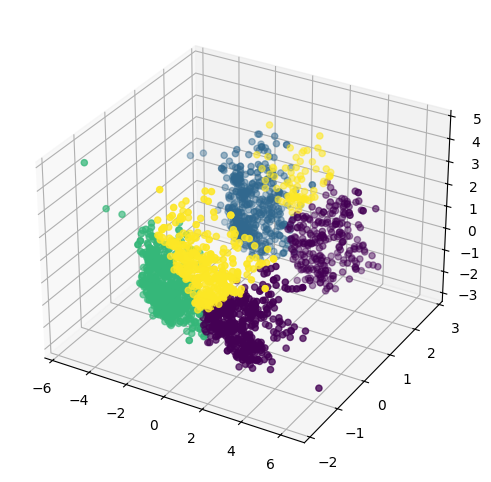

In [84]:
fig=plt.figure(figsize=(8,6))

ax = fig.add_subplot(111 , projection="3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c=labels)

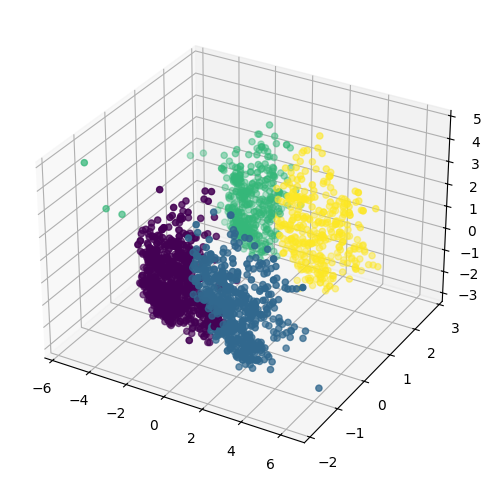

In [88]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4 , linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))

ax = fig.add_subplot(111 , projection="3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c=labels_agg)

In [ ]:
# Agglomerative better separates clusters as compared to KMeans

# Characterization

In [96]:
X["labels"] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='labels', ylabel='count'>

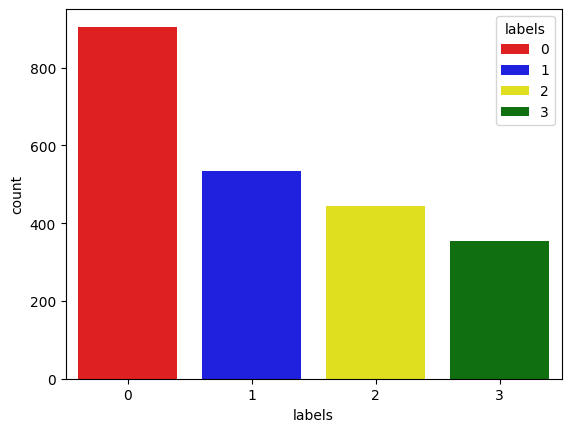

In [97]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["labels"] , palette=pal , hue=X["labels"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

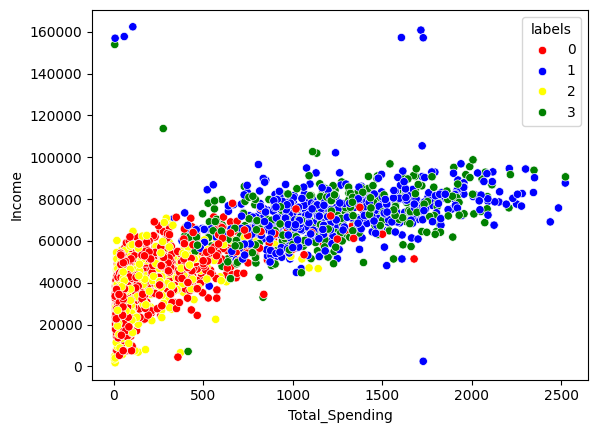

In [98]:
# we try to observe the corr matrix patterns now through scatter plots

sns.scatterplot(x=X["Total_Spending"] , y=X["Income"] , hue=X["labels"] , palette=pal)

In [99]:
# Cluster Summary
cluster_summary=X.groupby("labels").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels                                                                
0       39680.580110  48.914917           2.594475         3.153591   
1       72808.445693  49.202247           1.958801         5.687266   
2       36960.143018  48.319820           2.594595         2.713964   
3       70722.681303  50.504249           1.855524         5.790368   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
labels                                                                        
0                  0.969061           4.143646           6.307182  0.011050   
1                  5.498127           8.659176           3.580524  0.005618   
2                  0.837838           3.623874           6.659910  0.011261   
3                  5.014164           8.430595           3.728045  0.005666   

        Response        Age  Customer_Tenure_Days  Total_Spending  \
labels                       

# Insights & Strategies

## Cluster 0: Low Income, Low Engagement Customers

### 1. These are price-sensitive users
### 2. Strategy - Offer discounts, coupons, cashback

## Cluster 1: High Value Premium Customers

### 1. These are VIP customers
### 2. Strategy - Give exclusive offers / early access , recommend premium products

## Cluster 2: Low Income but Slightly Responsive

### 1. These are interested but hesitant buyers
### 2. Strategy - Use personalized recommendations, offer small discounts

## Cluster 3: High Income but Selective Buyers

### 1. These are smart, decision-making customers
### 2. Strategy - Highlight product value & quality